# __Elagin Matvey Dmitrievich SCT-125 Sarov DM Task 1 8 variant__

In [20]:
import pandas as pd
import numpy as np

# Определите (написав соответствующий код) сколько различных значений принимают переменные Product и Customer.

df = pd.read_csv('TRANSACTION.csv')
df.dropna()
task1 = df[['CUSTOMER', 'PRODUCT']].nunique() # Series
print(task1)

CUSTOMER    1001
PRODUCT       20
dtype: int64


In [21]:
# Найдите частые эпизоды с ограничением на размер правила равным 4, с использованием алгоритма и порога на поддержку согласно вашему варианту.
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

df_pivot = df.pivot(index='CUSTOMER', columns='TIME', values='PRODUCT')

# Чтобы заработал Енкодер нужно подогнать данные под список списков с последовательностью покупок продуктов каждого клиента.
df_fit = df_pivot.values.tolist()

te = TransactionEncoder() # Енкодер, кодирует данные так ,
# чтобы вместо последовательного списка покупок клиента, был список всех продуктов, и True/False в зависимости от наличия в эпизоде.
# te_fit инициализируем, иначе from "te" unpossible take name of columns.
te_fit = te.fit(df_fit).transform(df_fit)
# сохраняем данные в DataFrame
te_df = pd.DataFrame(te_fit, columns=te.columns_)
df_fp = fpgrowth(te_df, min_support=0.05, use_colnames=True, max_len=4)
print(df_fp.sort_values(by=['support'], ascending=False))

      support                      itemsets
7    0.599401                    (heineken)
8    0.487512                     (cracker)
0    0.485514                      (hering)
1    0.472527                      (olives)
2    0.402597                     (bourbon)
..        ...                           ...
89   0.051948      (cracker, corned_b, ham)
266  0.050949  (peppers, cracker, baguette)
181  0.050949  (cracker, avocado, baguette)
112  0.050949                (turkey, soda)
329  0.050949                 (soda, steak)

[360 rows x 2 columns]


In [22]:
# Найдите самый большой (где больше всего элементов) частый эпизод, содержащий продукт согласно вашему варианту. Какая у него поддержка?
def len_itemsets(rows):
    rows['len_itemsets'] = len(rows['itemsets'])
    return rows
# Сначала создадим столбец со значением величины эпизода.
df_len_itemsets = df_fp.apply(len_itemsets, axis = 1) # apply() - обход строк/столбцов с применением any func, axis = 1 (строки)
# Выделим эпизоды содержащие "peppers"
df_target = df_len_itemsets[df_len_itemsets['itemsets'].apply(lambda r : 'peppers' in r)]
# Среди эпизодов найдем самые большие
df_target = df_target[df_target['len_itemsets'] == df_target['len_itemsets'].max()]
# Среди наибольших эпизодов, найдем часто встречающийся
df_target = df_target[df_target['support'] == df_target['support'].max()]
print(df_target)

      support                              itemsets  len_itemsets
256  0.093906  (peppers, cracker, bourbon, chicken)             4


In [23]:
# На основе найденных частых эпизодов постройте ассоциативные правила с порогом на 
# достоверность согласно вашему варианту. Найдите правило с максимальным лифтом, 
# содержащем продукт из вашего варианта в левой части правила. Дайте ему письменную 
# словесную интерпретацию, укажите и объясните его числовые показатели: поддержку, 
# достоверность и подъем. 

df_ar = df_fp.copy(deep=False)
df_ar = association_rules(df_ar, metric='confidence', min_threshold=0.3) # min_threshold=0.3 - порог для метрики , в нашем случае достоверности

# Выберем правила где 'peppers' в левой части(antecedents(условие)), правая часть - consequents(следствие). 
df_ar_ = df_ar[df_ar['antecedents'].apply(lambda r: 'peppers' in r )]
# Выберем правило с наибольшим лифтом
df_ar_ = df_ar_[df_ar_['lift'] == df_ar_['lift'].max()]
print(df_ar_)
# В срезе DataFrame, можно увидеть ассоциативное правило такое, что при покупка авокадо и перцев, 
# покупатель как правило еще покупает яблоки и сардины. Частота такого эпизода по отношению ко всем равна 12,6%.
# Достоверность этого правила оценивается в 70%, значит с достаточно высокой вероятностью покупатель после корзины с авокадо и перцами 
#купит яблоки и сардины. Другими словами частота покупки всей последовательности по отношению к покупке только левой части.
# Лифт = 5.6, свидетельствует о зависимости правила, отношение зависимости покупки эпизода к независимой покупке продуктов отдельно,
#результат больше 1, значит зависимость между парой продуктов есть.
# В заключение по данным эпизодам, можно отметить, что при покупке авокадо и перцев с 70% вероятностью покупатель еще купит яблоки и сардины.
#Данное ассоциативное правило потверждает сильная зависимость покупки этих продуктов вместе.
#Но так как часть закупок такого эпизода по сравнению с другими мала, данное правило может никак не повлиять на дальнейшие использование этого правила.
#Скорее люди целенаправленно идут за покупкой такого набора и найдут в любой точке магазина.

            antecedents         consequents  antecedent support  \
911  (peppers, avocado)  (apples, sardines)            0.125874   

     consequent support  support  confidence      lift  representativity  \
911            0.125874  0.08991    0.714286  5.674603               1.0   

     leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
911  0.074066    3.059441         0.9424  0.555556   0.673143    0.714286  


     antecedents consequents  antecedent support  consequent support  \
0       (hering)  (heineken)            0.485514            0.599401   
1     (heineken)    (hering)            0.599401            0.485514   
2       (hering)   (cracker)            0.485514            0.487512   
3      (cracker)    (hering)            0.487512            0.485514   
9       (hering)    (olives)            0.485514            0.472527   
...          ...         ...                 ...                 ...   
1222   (chicken)   (cracker)            0.314685            0.487512   
1223   (bourbon)   (chicken)            0.402597            0.314685   
1224   (chicken)   (bourbon)            0.314685            0.402597   
1225  (corned_b)   (chicken)            0.390609            0.314685   
1226   (chicken)  (corned_b)            0.314685            0.390609   

       support  confidence      lift  representativity  leverage  conviction  \
0     0.287712    0.592593  0.988642               1.0 

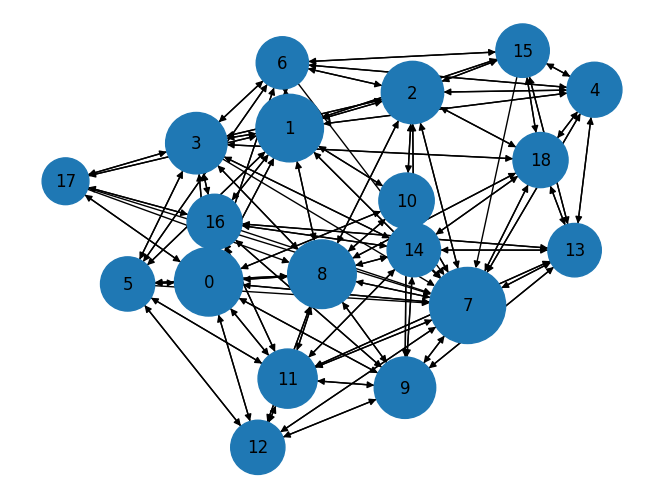

In [24]:
# Используя только двухместные правила постройте ориентированный граф, где вершины 
#элементы правила, их цвет (или размер) – поддержка элемента (item support), дуги – импликации (ориентированы в направлении от условия к следствию), 
#веса дугu – достоверности
import networkx as nx
G = nx.DiGraph() # Создаем объект класса, для построения графа
# df_g_s чтобы получить поддержку самого узла.
df_g_s = df_len_itemsets[df_len_itemsets['len_itemsets'] == 1].copy(deep=False)

df_g = association_rules(df_g_s)

# В задаче, построить узлы двухметсные(состоящие из двух продуктов), для этого отсортируем такие наборы из изначального FP-tree с длинной набора 2.
df_g=df_ar[df_ar[['antecedents', 'consequents']].apply(lambda r: len(r['antecedents']) == 1 and len(r['consequents']) == 1 , axis=1)]
print(df_g)

# далее инициализируем узлы графа, из ассоциативных правил
for i in range(df_g.shape[0]):
    r = df_g.iloc[i]
    G.add_node(r['antecedents'], support=df_g_s[df_g_s['itemsets'] == r['antecedents']]['support'].values,
                id=df_g_s[df_g_s['itemsets'] == r['antecedents']].index[0])
    G.add_node(r['consequents'], support=df_g_s[df_g_s['itemsets'] == r['consequents']]['support'].values,
                id=df_g_s[df_g_s['itemsets'] == r['consequents']].index[0])
    G.add_edge(r['antecedents'], r['consequents'], weight=r['confidence'])
    

node_sizes = [G.nodes[node]['support']*5000 for node in G.nodes()]
labels_ = {}
for node in G.nodes():
    # Используем оригинальный индекс как подпись
    labels_[node] = G.nodes[node]['id']


# Отобразим граф
import matplotlib.pyplot as plt
nx.draw(G, node_size=node_sizes, labels=labels_)

# На графе вместо метки набора , используется Index DF(df_g_s). Ниже закомментирован код для проверки.
# for node, attrs in DG.nodes(data=True):
#     print(f"Узел {node}: {attrs}")
# df_g_s.loc[78]

In [25]:
#Для данного графа рассчитайте меры центральности согласно вашему варианту и найдите 
#элемент с самой высокой мерой, а также какую меру имеет продукт из вашего варианта. 
# Треугольники отсутствуют
centr = nx.clustering(G)
print(max(centr.values()))

0.9024390243902439


In [26]:
def fill_rows(rows):
    arr_product = df_fit[rows.name]
    for str in rows.index:
        count = arr_product.count(str)
        rows[str] = count
    return rows
    
# Постройте числовую матрицу со счетчиком числа покупок в ячейках, клиентами по строкам и продуктами по столбцам.
df_matrix = pd.DataFrame(columns=df['PRODUCT'].unique(), index=df['CUSTOMER'].unique())

df_matrix.apply(fill_rows, axis=1)

,hering,corned_b,olives,ham,turkey,bourbon,ice_crea,baguette,soda,cracker,heineken,avocado,artichok,sardines,coke,peppers,apples,steak,chicken,bordeaux
0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0
2,0,0,0,1,1,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0
3,0,0,1,1,1,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0
4,1,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0,0,0,1,0,1,0,0,0,1,1,1,1,0,0,0,0,0,1,0
997,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
998,1,0,0,0,0,0,0,1,1,1,1,0,0,2,0,0,0,0,0,0
999,0,1,0,0,0,0,1,0,0,0,1,0,0,1,1,1,0,0,1,0


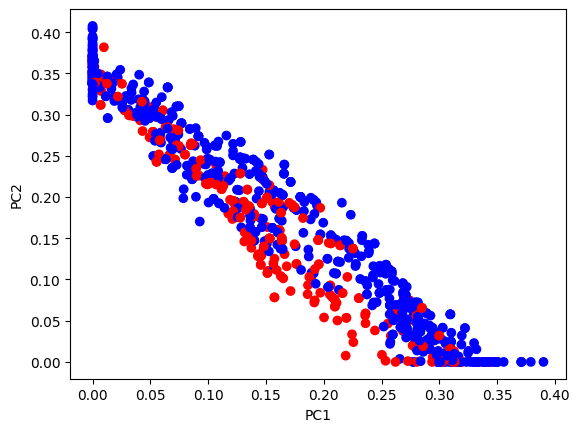

In [27]:
# С помощью метода из вашего варианта постройте линейную проекцию набора данных на 
#плоскость (2 компоненты) цветом укажите транзакции, содержащие продукт  вашего варианта. (NMF) 
from sklearn.decomposition import NMF

X = df_matrix.values # Исходные данные (N x M)
model = NMF(n_components=2, init='nndsvd',random_state=777)
W = model.fit_transform(X) # Матрица (N x n_components) проекция клиентов,
#отображает вес компоненты в каждой транкзации(например, вес покупки группы товаров: ham, turkey, bourbon)
H = model.components_ # Матрица (N_components x M), отображает вес каждого признака в конректной компоненте(например, 
#группа товаров имеет вес в компоненте, за счет этого можно дать определение компоненте, что она описывает) другими словами, раскрытие обобщения признаков
# print(W)
# print(H)
# print(W@H)
id_peppers = df_matrix[df_matrix['peppers'] > 0].index.values
# print(df_matrix)
fig, ax = plt.subplots()
# Red цвет для транзакций с peppers, другие blue
colors = []
for index in df_matrix.index:
    if index in id_peppers:
        colors.append('red')
    else: 
        colors.append('blue')
        
ax.scatter(W[:, 0], W[:, 1], color=colors)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()
# det_count_components()

In [28]:
# Теперь попробуем оценить наилучшее число компонент, методом логтя
# оценивать будем по квадратичной норме Фробениуса(расширение евклидовой нормы на матрицы)
def det_count_components():
    r = []
    X = df_matrix.values # Исходные данные (N x M)
    for n_k in range(1, len(df_matrix.columns)):
        model = NMF(n_components=n_k, init='nndsvd',random_state=777, max_iter=2000)
        W = model.fit_transform(X)
        H = model.components_
        absolute_err = np.linalg.norm(X - W@H, 'fro')
        err = absolute_err / np.linalg.norm(X, 'fro') # относительная ошибка
        r.append(err)
    
    fig, ax = plt.subplots()
    ax.plot(range(1, n_k+1), r)
    plt.show()

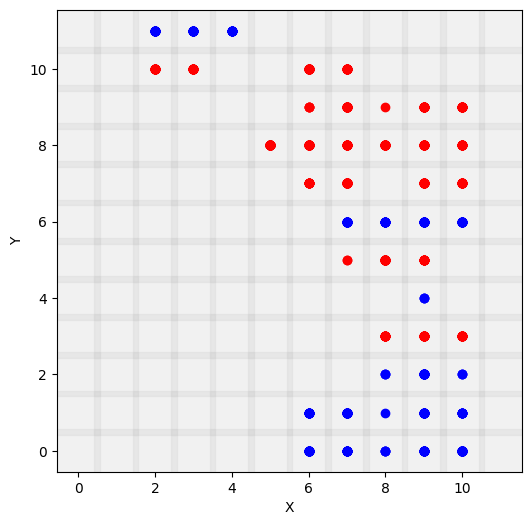

In [29]:
#С помощью метода из вашего варианта постройте нелинейную проекцию набора данных на 
#плоскость цветом укажите транзакции, содержащие продукт из вашего варианта. Не 
#указанные в задании параметры (например, размер решетки для SOM или число слоев в 
#автоэнкодере можно выбирать на свое усмотрение для получение наиболее удобной 
#визуализации). Дайте письменный комментарий, чем с вашей точки зрения для вашего 
#примера лучше или хуже нелинейная проекция). 
from minisom import MiniSom
# Подбор размера решетки осуществляется по формуле sqrt(5*sqrt(n_samples))
som_x_nodes = som_y_nodes = int(np.sqrt(5*np.sqrt(len(df_matrix.index)))) 
X_som = X.astype(np.float64)

som = MiniSom(som_x_nodes, som_y_nodes, df_matrix.shape[1]) # 1,2 - size grid, 3 - n-dimensional / sigma - параметр, для увелечения окрестности при обновлении весов соседей.
som.train(X_som, num_iteration = 300)

# В каждой транзакции есть нейрон победитель, который будет описывать эпизод к какому то кластеру
win_neurons = []
for x in X_som:
    som.winner(x) # Возвращает положение в решетке (row, column)  
    win_neurons.append(som.winner(x))

# Проекция
plt.figure(figsize=(6, 6))

# Решетка
for i in range(som_x_nodes):
    for j in range(som_y_nodes):
        plt.scatter(j, i, s=1000, c='lightgray', marker='s', alpha=0.3)
        
for point in win_neurons:
    if point[0] in id_peppers:
        plt.scatter(point[1], point[0], c='red')
    else:
        plt.scatter(point[1], point[0], c='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
# На примере с товаров peppers, линейная и нелинейная проекция показывают одни и те же результаты, количественные показатели не будут
#принимать отрицательные значения, а значит можно использовать линейную проекцию (NMF), но если нужно анализировать аномалии, то лучше применить (SOM)
#В данном случае, что при использовании компонент, можно заметить что pepper, встречается часто в покупках, так и в нелинейной проекции (кластеризации)
# перцы не играют большую роль при описании кластеров.

In [ ]:
# Из исходной матрицы (из пункта 7) согласно вашему варианту отберите указанное число 
#независимых переменных с использованием метода VarClus/ Glasso/пошагового на ваш 
#выбор.
# Glasso
from sklearn.covariance import empirical_covariance, graphical_lasso
# Ковариационная матрица
emp_cov = empirical_covariance(X)
covariance, precision_matrix = graphical_lasso(emp_cov, alpha=0.05)
# print(precision_matrix)
df_matrix_dependent = pd.DataFrame(precision_matrix, index=df_matrix.columns, columns=df_matrix.columns)

# Первые n шесть
n_count = 6
for idx,s in df_matrix_dependent.iterrows(): 
    s_t = s[s == 0].index
    if len(s_t.values) >= n_count :
        diff = len(s_t.values)-n_count
        print(f'{idx} независим с {s_t[:n_count].values}')
        break
    else:
        diff = n_count-len(s_t.values)
        n_count = diff
        print(f'{idx} независим с {s_t.values}')
        